In [1]:
import sys
import os

# Adiciona o diretório raiz ao Python path
sys.path.append('../../')

from item_agent import ItemAgent
from recommendation_agent import RecommendationAgent
from agent_sentiment_analysis import SentimentalAgent

## Inicializa o agente Recomendador (RA)
ra = RecommendationAgent()

## Inicializa o agente Item (IA)
ita = ItemAgent()

## Inicializa o agente Análise de Sentimentos (AAS)
sa = SentimentalAgent()

/Users/carlosalberto/Documents/projects/ai/TEESI_2025/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
"""from langchain_openai import OpenAIEmbeddings
from types import SimpleNamespace

# Crie um prompt input aqui para inserir a chave da OpenAI
os.environ["OPENAI_API_KEY"] = input("Enter your OpenAI API Key: ")

gpt = SimpleNamespace(
                name="gpt-4o-mini",
                provider="openai",
                environmentKey="OPENAI_API_KEY",
                embeddings=OpenAIEmbeddings(api_key=os.environ["OPENAI_API_KEY"]),
                collection_name = "dataset_enem_gpt_4o_mini",
                chromadb_path="./../../data_agent_1/chroma_db_2022")"""

'from langchain_openai import OpenAIEmbeddings\nfrom types import SimpleNamespace\n\n# Crie um prompt input aqui para inserir a chave da OpenAI\nos.environ["OPENAI_API_KEY"] = input("Enter your OpenAI API Key: ")\n\ngpt = SimpleNamespace(\n                name="gpt-4o-mini",\n                provider="openai",\n                environmentKey="OPENAI_API_KEY",\n                embeddings=OpenAIEmbeddings(api_key=os.environ["OPENAI_API_KEY"]),\n                collection_name = "dataset_enem_gpt_4o_mini",\n                chromadb_path="./../../data_agent_1/chroma_db_2022")'

In [3]:
from types import SimpleNamespace
from langchain_google_vertexai import VertexAIEmbeddings

 # Crie um prompt input aqui para inserir a chave da OpenAIos.environ["OPENAI_API_KEY"] =  
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] =  input("Enter your Google API Key: ")

#Gemini
gemini  = SimpleNamespace(
                        name="gemini-2.0-flash",
                        provider="google_vertexai",
                        environmentKey="GOOGLE_APPLICATION_CREDENTIALS",
                        embeddings=VertexAIEmbeddings(model_name="gemini-embedding-001"),
                        collection_name = "dataset_enem_gemini-2.0-flash",
                        chromadb_path="./../../data_agent_1/chroma_db_2022")


/Users/carlosalberto/Documents/projects/ai/TEESI_2025/venv/lib/python3.9/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [4]:
from langchain.chat_models import init_chat_model
from langchain.memory import ConversationBufferMemory

# Configurações dos testes

#Definir o modelo;
ra.model = gemini

ita.model = gemini

sa.model = gemini

#Definir o chat
ra.llm = init_chat_model(
            ra.model.name, 
            model_provider=ra.model.provider,
            temperature=0.2)

ita.llm = init_chat_model(
            ra.model.name, 
            model_provider=ra.model.provider,
            temperature=0.2)

sa.llm = init_chat_model(
            sa.model.name, 
            model_provider=sa.model.provider,
            temperature=0.0)

#Definir a memória
ra.memory = []
ita.memory = []

# Definir o Item de Agente ITA

ita.embeddings = ita.model.embeddings

ra.item_agent = ita


# Definir o banco vetorial
ita.vector_store = ita._load_vector_store()



/Users/carlosalberto/Documents/projects/ai/TEESI_2025/experiments/RQ1/../../item_agent.py:18: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  return Chroma(


In [5]:
validation_dict ={
  "linguagens, códigos e suas tecnologias" : ["linguagem", "português", "inglês", "espanhol", "literatura", "artes", "educação física"],
  "ciências humanas e suas tecnologias": ["história", "geografia", "filosofia", "sociologia"],
  "ciências da natureza e suas tecnologias" : ["física", "química", "biologia"],
  "matemática e suas tecnologias" : ["matemática", "geometria", "álgebra"]
}
                

In [6]:
def identificar_area(prompt, answer):
    prompt_lower = prompt.lower()  # normaliza para evitar problemas com maiúsculas/minúsculas
    for area, disciplinas in validation_dict.items():
        for disciplina in disciplinas:
            if disciplina in prompt_lower:
                if area in answer.lower():
                    counter["Correct"] += 1
                else:
                    counter["Incorrect"] += 1



def validar_resposta(answer, resposta_correta):
    if resposta_correta.lower() in answer.lower():
        counter["Correct"] += 1
    else:
        counter["Incorrect"] += 1

In [ ]:
#Definição do Prompt Flow 

#disciplinas = ["linguagem", "português", "inglês", "espanhol", "literatura", "artes", "educação física",
#                "história", "geografia", "filosofia", "sociologia",     
#                "física", "química", "biologia",    
#                "matemática", "geometria", "álgebra"]  

#niveis = ["Fácil", "Médio", "Difícil"]  

disciplinas = ["linguagem"] 

niveis = ["Fácil", "Médio", "Difícil"] 

respostas = ["A","B","C","D","E"] 



In [8]:
#Prompt Flow
pf1 = [
    {"human": "Olá"},
    {"human": f"[disciplina]"},
    {"human": f"[nivel]"},
    {"human": f"Resposta: [answer]"}
]

In [9]:
from datasets import load_dataset, Features, Value
import re
import random

features = Features({
        "ano": Value("int64"),
        "enunciado": Value("string"),
        "label": Value("int64"),
        "cor_prova": Value("string"),
        "pos_item": Value("string"),
        "descricao_area": Value("string"),
        "area": Value("string"),
        "cod_prova": Value("int64"),
        "CO_POSICAO": Value("float64"),
        "SG_AREA": Value("string"),
        "CO_ITEM": Value("float64"),
        "TX_GABARITO": Value("string"),
        "CO_HABILIDADE": Value("float64"),
        "IN_ITEM_ABAN": Value("float64"),
        "TX_MOTIVO_ABAN": Value("string"),
        "NU_PARAM_A": Value("float64"),
        "NU_PARAM_B": Value("float64"),
        "NU_PARAM_C": Value("float64"),
        "TX_COR": Value("string"),
        "CO_PROVA": Value("float64"),
        "TP_LINGUA": Value("string"),
        "IN_ITEM_ADAPTADO": Value("float64")
    })

# Carregar o dataset a partir do diretorio
ano=2022
questoes = load_dataset("json", data_dir=f"../../datasets/enem/{ano}", features=features)


# Imprimir o gabarito da questão encontrada
def buscarGabaritoQuestao(pos_item):
    
    questao = questoes['train'].filter(lambda x: x['pos_item'] == pos_item)

    return questao[0]['TX_GABARITO']

def IsNegativeGrading(answer):
    padrao = r".*resposta.*?(incorret\w*|errad\w*)"
    match = re.search(padrao, answer, flags=re.IGNORECASE)
    #print("entrou extrairRespostaLLM")
    if match:
        #print("entrou match")
        status_completo = match.group(0)
        # match.group(1) captura a palavra inteira encontrada (ex: 'incorretissima')
        palavra_chave = match.group(1)
        print(f"Padrão encontrado: '{status_completo}' | Radical/Palavra-chave: '{palavra_chave}'")
        return True;
    else:
        return False;



In [10]:
counter = {
    "Real":[],
    "Predicted":[],
    "Correct_grading": 0,
    "Incorrect_grading": 0,
    "False_Positive": 0,
    "False_Negative": 0,
    "Found_question": 0,
    "Not_found_question": 0,
    "Total_tests": 0,
    "Questions": [],
    "Fail": 0
}

In [11]:
def sentiment_analysis(prompt):
    state = sa.get_response({"text": prompt})
    return state["answer"]

In [12]:
def IsNegativeGranding2(answer):
    result = sentiment_analysis(answer)
    if "negativo" in result.lower():
        return True
    else:
        return False

In [13]:
question = {"text" : ""}

In [ ]:
import re, unicodedata

def validarRespostaLLM(author, answer, answer_user):
    # Normaliza Unicode e remove acentos compostos
    normalized = unicodedata.normalize("NFKD", question["text"])
    normalized = ''.join(c for c in normalized if not unicodedata.combining(c))
    # Remove caracteres invisíveis e espaços estranhos
    normalized = (normalized.replace('\xa0', ' ')
           .replace('\u2028', '')
           .replace('\u2029', '')
           .replace('\u200b', '')
           .replace('\r', ''))
    padrao_case_insensitive = r"questao[^\d]{0,10}(\d{1,3})"

    #print(question["text"])
    match = re.search(padrao_case_insensitive, normalized, flags=re.IGNORECASE | re.DOTALL)
   
    #print("entrou 1")
    print(f"{author}: {match}")

    if author == "ai" and match:
        #print("entrou 2")
        print(match)
        gabarito = buscarGabaritoQuestao(match.group(1))
        #avaliacaoNegativa = IsNegativeGrading(answer)
        avaliacaoNegativa = IsNegativeGranding2(answer)

        #print(f"Questão encontrada: -> '{match.group(1)}'")
        #print(f"Gabarito correto: -> '{gabarito}'")
        #print(f"Resposta do usuário: -> '{answer_user}'")
        #print(f"Avaliação negativa: -> '{avaliacaoNegativa}'")

        if gabarito is None:
            print("Gabarito não encontrado para a questão.")
            counter["Not_found_question"] += 1
            return
        else:
            counter["Found_question"] += 1
            counter["Questions"].append(match.group(1))
            
            # Se a resposta do LLM indicar que a resposta do usuário está incorreta 
            # e a resposta do usuário não estiver no gabarito, conta como "correct_grading".
            # Pois de fato o LLM avaliou corretamente a resposta do usuário.
        
            counter["Real"].append(avaliacaoNegativa)
            counter["Predicted"].append(answer_user != gabarito)  
      
         

        #if  ((answer_user != gabarito) == avaliacaoNegativa):
        #    counter["Correct_grading"] += 1
        #else:
        #    counter["Incorrect_grading"] += 1

        #if  ((answer_user == gabarito) and avaliacaoNegativa):
        #    counter["False_Negative"] += 1

        #if  ((answer_user != gabarito) and not avaliacaoNegativa):
        #    counter["False_Positive"] += 1

        #procurar uma matriz de confusão para corrigir isso.

        #Interpretação geral da matriz de confusão
        #Para um problema binário (duas classes):

	    #Previsto: Positivo	Previsto: Negativo
        #Real: Positivo	VP (Verdadeiro Positivo)	FN (Falso Negativo)
        #Real: Negativo	FP (Falso Positivo)	VN (Verdadeiro Negativo)

        #VP (True Positive) -> modelo acertou o positivo. O aluno acertou e o LLM disse que estava correto.
        #VN (True Negative) -> modelo acertou o negativo. O aluno errou e o LLM disse que estava incorreto.
        #FP (False Positive) -> modelo errou dizendo “positivo” quando era “negativo”. O aluno errou e o LLM disse que estava correto.
        #FN (False Negative) -> modelo errou dizendo “negativo” quando era “positivo”. O aluno acerta e o LLM disse que estava incorreto.
    else:
        counter["Fail"] += 1

In [15]:
def performFlowTest(p, disciplina, nivel, chat):
    if p["human"] == "[disciplina]":
        prompt = p["human"].replace("[disciplina]", disciplina)
        answer = chat(prompt)
    elif p["human"] == "[nivel]":
        prompt = p["human"].replace("[nivel]", nivel)
        answer = chat(prompt)
        question["text"] = answer
    elif "[answer]" in p["human"]:
        answer_user = random.choice(respostas)
        prompt = p["human"].replace("[answer]", answer_user)
        answer = chat(prompt)
        validarRespostaLLM("ai", answer, answer_user)
        counter["Total_tests"] += 1
    else:
        prompt = p["human"]
        answer = chat(prompt)

In [16]:
import random

def chat(prompt):
    ra.memory.append({"human": prompt})
    state = ra.get_response({"question": prompt})
    ra.memory.append({"ai":state["answer"]})
    return state["answer"]

tentativas = range(5)
# percorre a lista e substitui quando encontrar
for disciplina in disciplinas:
    for nivel in niveis:
        for i in tentativas:
            for p in pf1:
                performFlowTest(p, disciplina, nivel, chat)
        

print(counter)

ai: <re.Match object; span=(15, 25), match='Questao 24'>
<re.Match object; span=(15, 25), match='Questao 24'>
Questão encontrada: -> '24'
Gabarito correto: -> 'E'
Resposta do usuário: -> 'E'
Avaliação negativa: -> 'False'
ai: <re.Match object; span=(113, 123), match='Questao 10'>
<re.Match object; span=(113, 123), match='Questao 10'>


Filter:   0%|          | 0/148 [00:00<?, ? examples/s]

Questão encontrada: -> '10'
Gabarito correto: -> 'C'
Resposta do usuário: -> 'C'
Avaliação negativa: -> 'False'
ai: <re.Match object; span=(15, 25), match='Questao 13'>
<re.Match object; span=(15, 25), match='Questao 13'>
Questão encontrada: -> '13'
Gabarito correto: -> 'B'
Resposta do usuário: -> 'E'
Avaliação negativa: -> 'True'
ai: <re.Match object; span=(15, 25), match='Questao 28'>
<re.Match object; span=(15, 25), match='Questao 28'>
Questão encontrada: -> '28'
Gabarito correto: -> 'B'
Resposta do usuário: -> 'D'
Avaliação negativa: -> 'True'
ai: <re.Match object; span=(15, 25), match='Questao 08'>
<re.Match object; span=(15, 25), match='Questao 08'>
Questão encontrada: -> '08'
Gabarito correto: -> 'A'
Resposta do usuário: -> 'C'
Avaliação negativa: -> 'True'
ai: <re.Match object; span=(113, 123), match='Questao 22'>
<re.Match object; span=(113, 123), match='Questao 22'>
Questão encontrada: -> '22'
Gabarito correto: -> 'E'
Resposta do usuário: -> 'C'
Avaliação negativa: -> 'True'


Filter:   0%|          | 0/148 [00:00<?, ? examples/s]

Questão encontrada: -> '09'
Gabarito correto: -> 'A'
Resposta do usuário: -> 'C'
Avaliação negativa: -> 'True'
ai: <re.Match object; span=(113, 123), match='Questao 15'>
<re.Match object; span=(113, 123), match='Questao 15'>


Filter:   0%|          | 0/148 [00:00<?, ? examples/s]

IndexError: Invalid key: 0 is out of bounds for size 0

In [17]:
for chat in ra.memory:
    for author, menssage in chat.items():
        print(f"{author}: {menssage}")
        print("------")

human: Olá
------
ai: Olá! Sou um agente de recomendação especializado em questões do ENEM. Para começarmos, qual disciplina você gostaria de estudar? As opções são: linguagem, português, inglês, espanhol, literatura, artes, educação física, história, geografia, filosofia, sociologia, física, química, biologia, matemática, geometria ou álgebra.

------
human: linguagem
------
ai: Entendi, você gostaria de questões de linguagem.
Notei que é a primeira vez que você responde a questões do ENEM por aqui.
Desta forma, vamos começar com o nível de dificuldade "Fácil", isto se você não tiver nenhuma preferência.

------
human: Fácil
------
ai: Informações da Questão 24 do Ano de 2022 na Cor da prova: AZUL

Ano da prova: 2022

Cor da prova: AZUL

Área de Conhecimento da questão: linguagens, códigos e suas tecnologias

Dificuldade da Questão: Fácil

Questão ou Item de Prova:

QUESTÃO 24
O complexo de falar difícil
O que importa realmente é que o(a) detentor(a)
do notável saber jurídico saiba qu

In [18]:
import re


#O Usuario responde a pergunta com uma resposta correta ou incorreta.
for chat in ra.memory:
    for author, menssage in chat.items():
        padrao_case_insensitive = r"questão\s+(\d+)"
        match = re.search(padrao_case_insensitive, menssage)
        
        if author == "ai" and match:
            print(f"Questão encontrada: -> '{match.group(1)}'")
            gabarito = buscarGabaritoQuestao(match.group(1))
            print(f"Gabarito correto: -> '{gabarito}'")



In [19]:
print(f"Acertos: {counter['Correct_grading']}")
print(f"Falsos Positivos: {counter['False_Positive']}")
print(f"Falsos Negativos: {counter['False_Negative']}")
print(f"Total de testes: {counter['Total_tests']}")
print(f"Questões encontradas: {counter['Questions']}")

total = counter['Total_tests'] - counter['Not_found_question']

# Accuracy = Acertos / Total de questões respondidas - Proporção de respostas corretas.
acuracy = counter['Correct_grading'] / total if total > 0 else 0
print(f"Acuracy: {acuracy}")

# Precision = Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Positivos)
precision = counter['Correct_grading'] / (counter['Correct_grading'] + counter['False_Positive']) if (counter['Correct_grading'] + counter['False_Positive']) > 0 else 0
print(f"Precision: {precision}")

# Recall = Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Negativos)
recall = counter['Correct_grading'] / (counter['Correct_grading'] + counter['False_Negative']) if (counter['Correct_grading'] + counter['False_Negative']) > 0 else 0
print(f"Recall: {recall}")

Acertos: 0
Falsos Positivos: 0
Falsos Negativos: 0
Total de testes: 8
Questões encontradas: ['24', '10', '13', '28', '08', '22', '09']
Acuracy: 0.0
Precision: 0
Recall: 0


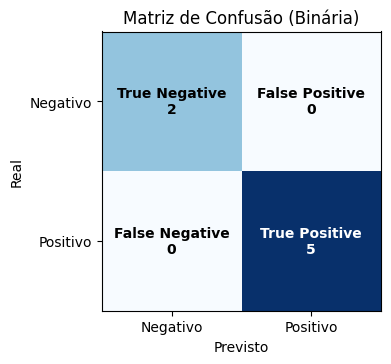

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np


# Gera matriz
cm = confusion_matrix(counter["Real"], counter["Predicted"])

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap=plt.cm.Blues)

# Rótulos dos eixos
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negativo', 'Positivo'])
ax.set_yticklabels(['Negativo', 'Positivo'])

# Adiciona os rótulos clássicos (TP, TN, FP, FN)
labels = np.array([["True Negative", "False Positive"],
                   ["False Negative", "True Positive"]])

# Anota os valores + legendas
for i in range(2):
    for j in range(2):
        ax.text(j, i,
                f"{labels[i, j]}\n{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black",
                fontsize=10, fontweight="bold")

plt.title("Matriz de Confusão (Binária)")
plt.tight_layout()
plt.show()
